In [1]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [10]:
from src.data import SPGDataset
import numpy as np
dataset = SPGDataset(root="../data/spg")

def normalize_absolute_coords(points):
	centroid = np.mean(points, axis=0)
	points -= centroid
	furthest_distance = np.max(np.sqrt(np.sum(abs(points)**2,axis=-1)))
	points /= furthest_distance

	return points

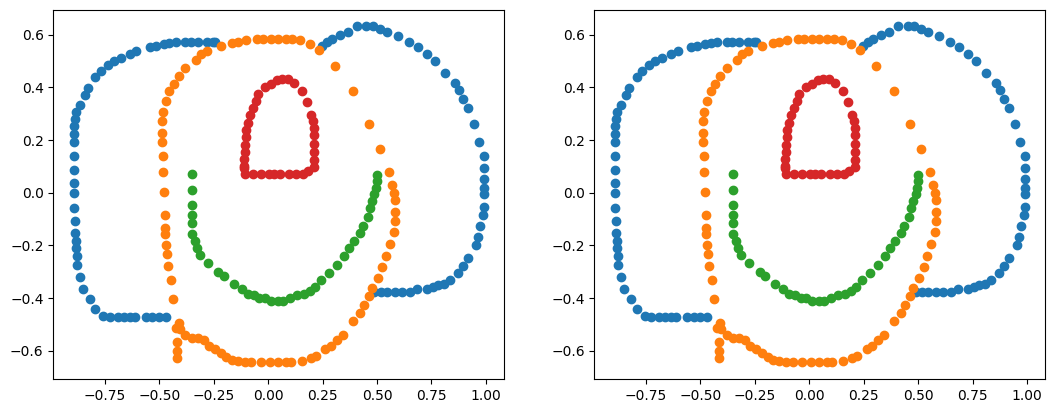

In [21]:
pos1 = dataset[67]['pos_absolute']
pos2 = normalize_absolute_coords(dataset[67]['pos_relative'].cumsum(axis=0))

import matplotlib.pyplot as plt
labels = dataset[67]['label']

fig, axis = plt.subplots(1, 2, figsize=(6.4 * 2, 4.8))

for label in np.unique(labels):
    axis[0].scatter(pos1[label == labels][:, 0], pos1[label == labels][:, 1])

for label in np.unique(labels):
    axis[1].scatter(pos2[label == labels][:, 0], pos2[label == labels][:, 1])
    